In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from package.RankAMIP.logistic import run_logistic_regression
from package.RankAMIP.data_script import make_BT_design_matrix
from package.RankAMIP.logistic import LogisticAMIP
from package.RankAMIP.logistic import find_closest_matchups
from package.RankAMIP.logistic import isRankingRobust
from package.RankAMIP.data_script import *

### How Robust is the Multi-turn Benchmark to Data-Dropping?

The MT-Bench (Multi-Turn Benchmark) is a curated set of 80 multi-turn dialogue prompts designed to evaluate the conversational and instruction-following capabilities of large language models (LLMs). Each prompt simulates realistic, multi-turn interactions that test a model's ability to maintain context, reason logically, and provide coherent responses across various domains, including general knowledge, reasoning, programming, and open-ended tasks.

### Load Data

In [14]:
# Import datasets from 
# https://huggingface.co/datasets/lmsys/mt_bench_human_judgments
from datasets import load_dataset
ds = load_dataset("lmsys/mt_bench_human_judgments")

In [16]:
# inspect the available splits
print(ds)  
# MT-bench has both human and a gpt4-judge data.
gpt4_pair = ds["gpt4_pair"] 
human = ds["human"] 
# look at the first example
print(gpt4_pair[0])

DatasetDict({
    gpt4_pair: Dataset({
        features: ['question_id', 'model_a', 'model_b', 'winner', 'judge', 'conversation_a', 'conversation_b', 'turn'],
        num_rows: 2400
    })
    human: Dataset({
        features: ['question_id', 'model_a', 'model_b', 'winner', 'judge', 'conversation_a', 'conversation_b', 'turn'],
        num_rows: 3355
    })
})
{'question_id': 81, 'model_a': 'alpaca-13b', 'model_b': 'claude-v1', 'winner': 'model_b', 'judge': 'gpt4_pair', 'conversation_a': [{'content': 'Compose an engaging travel blog post about a recent trip to Hawaii, highlighting cultural experiences and must-see attractions.', 'role': 'user'}, {'content': 'I recently had the pleasure of visiting Hawaii and it quickly became one of my favorite places. From the stunning beaches to the lush mountains, this place has it all. The people are incredibly friendly and the culture is alive and well. One of the highlights of my trip was visiting the Polynesian Cultural Center. Here, I was able 

In [17]:
df = gpt4_pair.to_pandas()
df.shape

(2400, 8)

In [18]:
# create a column winner_model_a, which is 1 if model_a is preferred, 0 if model_b is preferred
df['winner_model_a'] = df['winner'].apply(lambda x: 1 if x == 'model_a' else 0)
# create a column called winner_tie that is 1 if the winner is 'tie', else 0
df['winner_tie'] = df['winner'].apply(lambda x: 1 if x == 'tie' else 0)
df.head()

,question_id,model_a,model_b,winner,judge,conversation_a,conversation_b,turn,winner_model_a,winner_tie
0,81,alpaca-13b,claude-v1,model_b,gpt4_pair,[{'content': 'Compose an engaging travel blog ...,[{'content': 'Compose an engaging travel blog ...,1,0,0
1,81,alpaca-13b,claude-v1,model_b,gpt4_pair,[{'content': 'Compose an engaging travel blog ...,[{'content': 'Compose an engaging travel blog ...,2,0,0
2,81,alpaca-13b,gpt-3.5-turbo,model_b,gpt4_pair,[{'content': 'Compose an engaging travel blog ...,[{'content': 'Compose an engaging travel blog ...,1,0,0
3,81,alpaca-13b,gpt-3.5-turbo,model_b,gpt4_pair,[{'content': 'Compose an engaging travel blog ...,[{'content': 'Compose an engaging travel blog ...,2,0,0
4,81,alpaca-13b,gpt-4,model_b,gpt4_pair,[{'content': 'Compose an engaging travel blog ...,[{'content': 'Compose an engaging travel blog ...,1,0,0


In [19]:
ties = df[df['winner_tie'] == 1]
print(f"Number of ties: {len(ties)}")
# proportion of ties.
print(f"Proportion of ties: {len(ties) / len(df):.2%}")
# note, the proportion of ties is 9.17% for the LLM-as-judge data and 23.25% for the human-as-judge data.

Number of ties: 220
Proportion of ties: 9.17%


In [20]:
rawBT = df[['model_a', 'model_b', 'winner_model_a', 'winner_tie']] # ties dropped there were 2180 rows.
rawBT.head()
rawBT.shape

(2400, 4)

In [21]:
# how to get the unique names in both columns
model_a_names = df['model_a'].unique()
model_b_names = df['model_b'].unique()
# combine the two arrays and get the unique names
model_names = np.unique(np.concatenate((model_a_names, model_b_names)))
# print the number of unique model names
print(f"Number of unique model names: {len(model_names)}")

Number of unique model names: 6


In [22]:
for model in model_names:
    filtered = df[
        (df['model_a'] == model) | 
        (df['model_b'] == model)
    ]
    print(f"{model}: {filtered.shape[0]}")

alpaca-13b: 800
claude-v1: 800
gpt-3.5-turbo: 800
gpt-4: 800
llama-13b: 800
vicuna-13b-v1.2: 800


In [23]:
# make the BT design matrix.
X, y, player_to_id = make_BT_design_matrix(rawBT, weight_tie = True)
X.shape, y.shape

((4800, 5), (4800,))

### Uniform Data-dropping

In [12]:
# compute BT scores.
model_full = run_logistic_regression(X, y)

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)

# combine bt_scores with player names
id_to_player = {v: k for k, v in player_to_id.items()}
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}

# Determine the original top model
top_model_original = max(bt_scores_with_names.items(), key=lambda x: x[1])[0]
print("original top 5 models: ", dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True)[:5]))

num_trials = 100
num_agree = 0

for trial in range(num_trials):
    indices = np.random.choice(X.shape[0], size=int(X.shape[0]*0.01), replace=False)
    X_dropped = np.delete(X, indices, axis=0)
    y_dropped = np.delete(y, indices, axis=0)

    model_dropped = run_logistic_regression(X_dropped, y_dropped)
    bt_scores_dropped = np.insert(model_dropped.coef_[0], 0, 0)
    bt_scores_with_names_dropped = {id_to_player[i]: score for i, score in enumerate(bt_scores_dropped)}
    top_model_dropped = max(bt_scores_with_names_dropped.items(), key=lambda x: x[1])[0]
    if top_model_dropped == top_model_original:
        num_agree += 1

    # Optional: Show some progress every 10 iterations
    if (trial+1) % 10 == 0:
        print(f"Completed {trial+1} trials...")

print(f"Fraction of times top-ranked model stays the same after dropping 1% of the data: {num_agree/num_trials:.2f}")

original top 5 models:  {'gpt-4': 3.9727392153647534, 'claude-v1': 3.652117926719541, 'gpt-3.5-turbo': 2.464668591617266, 'vicuna-13b-v1.2': 1.3357641153240816, 'alpaca-13b': 0.0}
Completed 10 trials...
Completed 20 trials...
Completed 30 trials...
Completed 40 trials...
Completed 50 trials...
Completed 60 trials...
Completed 70 trials...
Completed 80 trials...
Completed 90 trials...
Completed 100 trials...
Fraction of times top-ranked model stays the same after dropping 1% of the data: 1.00


#### Bootstrap Confidence Intervals

In [24]:
import importlib
import compute_CIs
importlib.reload(compute_CIs)

<module 'compute_CIs' from '/Users/JennyH/Desktop/IsRankingRobust/compute_CIs.py'>

In [25]:
BOOTSTRAP_ROUNDS = 100
### Obtain Bootstrap Confidence Intervals.
np.random.seed(42)
bootstrap_elo_lu = compute_CIs.get_bootstrap_result(df, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap: 100%|██████████| 100/100 [00:01<00:00, 68.46it/s]


In [26]:
bootstrap_elo_lu.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_elo_lu.quantile(0.025)
ci_upper = bootstrap_elo_lu.quantile(0.975)
ci_med = bootstrap_elo_lu.median()
ci_df = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper
})
ci_df

,2.5%,Median,97.5%
gpt-4,1326.182170,1374.537186,1422.973437
gpt-3.5-turbo,1054.741739,1082.886147,1113.852247
claude-v1,1000.000000,1000.000000,1000.000000
llama-13b,1000.000000,1000.000000,1000.000000
vicuna-13b-v1.2,874.670210,906.070641,930.485579
alpaca-13b,594.829318,636.159382,673.898524


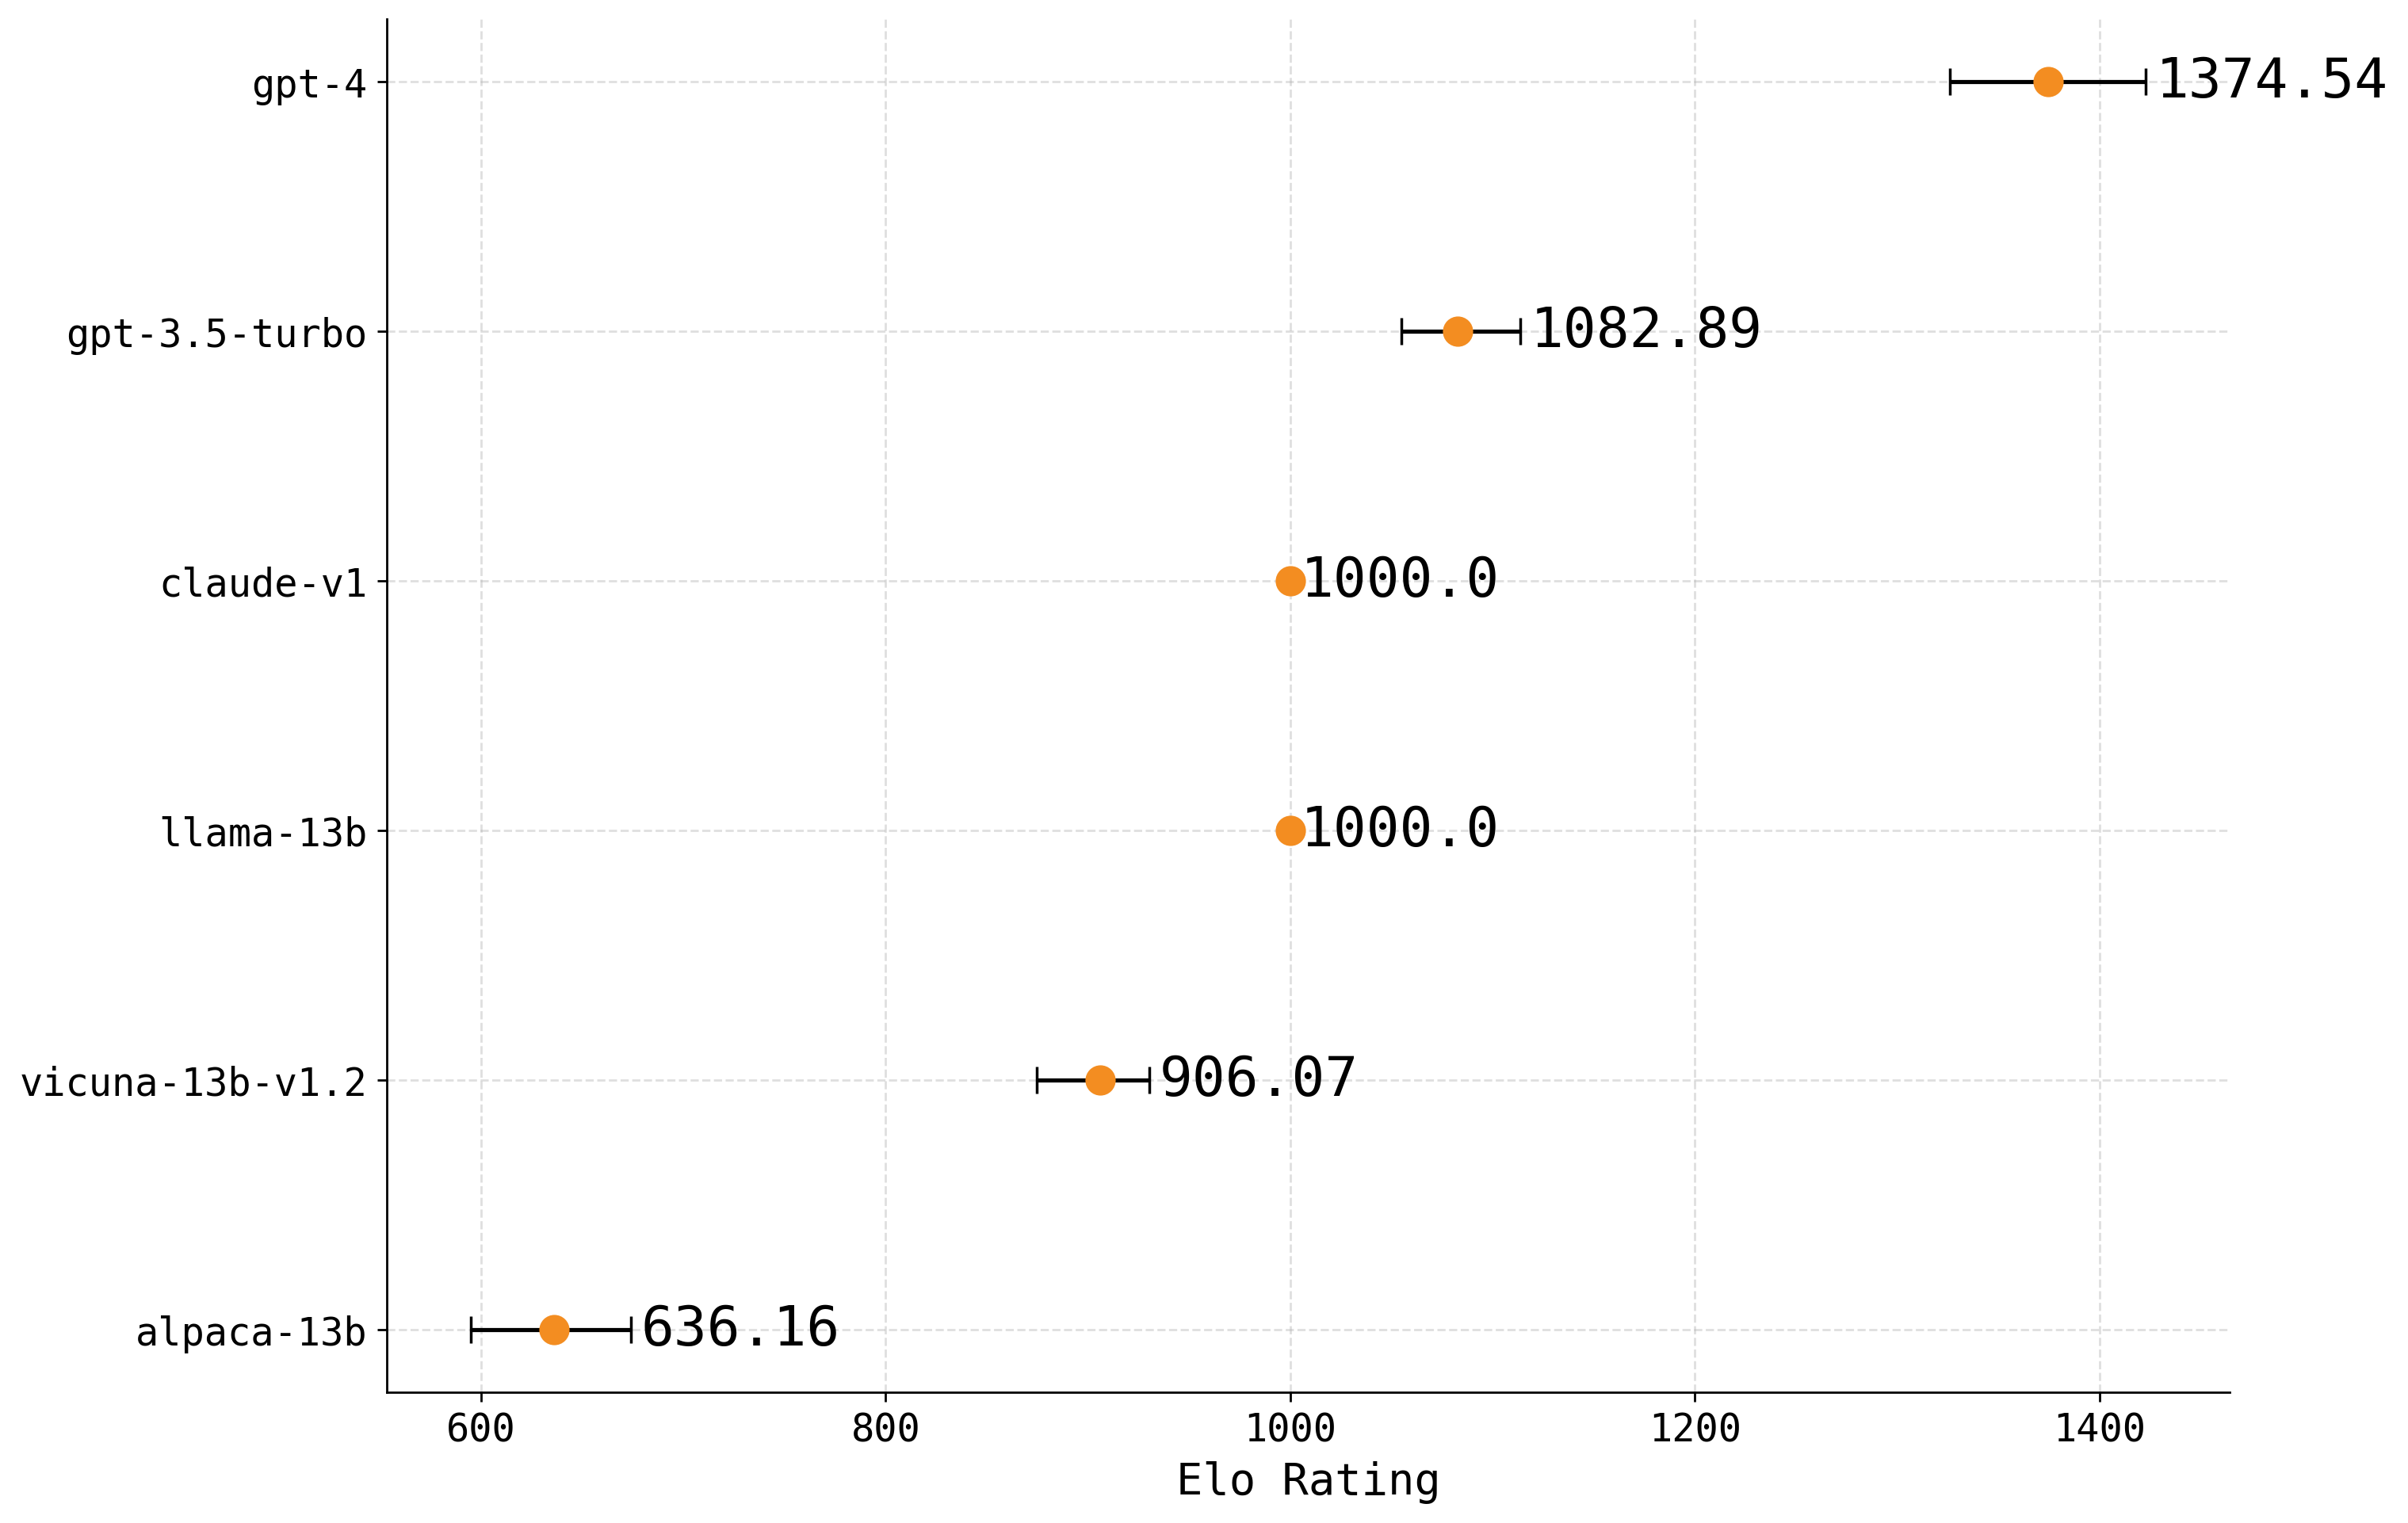

In [27]:
compute_CIs.plot_elo_confidence_intervals(ci_df.head(10))

#### Identify the pool of influential points for auditing Top-1 Robustness

In [ ]:
import math
k = 1
alphaN = math.floor(0.04 * len(df))
print(alphaN)
chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, top1_mis_indices = isRankingRobust(k, alphaN, X, y,  weighted = True)
# remove top_1_mis from df
df_dropped = df.drop(top1_mis_indices).reset_index(drop=True)

len(df), len(df_dropped)

BOOTSTRAP_ROUNDS = 100
bootstrap_top1_mis_dropped = compute_CIs.get_bootstrap_result(df_dropped, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap_top1_mis_dropped.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_top1_mis_dropped.quantile(0.025)
ci_upper = bootstrap_top1_mis_dropped.quantile(0.975)
ci_med = bootstrap_top1_mis_dropped.median()
ci_df_dropped = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper,
})
print(ci_df_dropped.head())

print(f'fraction of preferences dropped: {num_dropped / len(df)}')
compute_CIs.plot_elo_confidence_intervals(ci_df_dropped.head(10), title=f"Top 10 Elo Ratings Upon Removing {num_dropped} out of {len(df)} of Preferences")


96


bootstrap:  71%|███████   | 71/100 [00:00<00:00, 77.08it/s]

#### Run Top-k Robustness Check.

In [ ]:
ks = [1, 3, 5]

results = {}
for k in ks:
    alphaN = 1
    chatbotA = -1
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices = isRankingRobust(k, alphaN, X, y, weighted = True)
        results[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatIndices)
        alphaN += 1

In [ ]:
# find the (k, alpha N) pairs that are non-robust.
results_nonrobust = {k: v for k, v in results.items() if v[0] != -1}
results_nonrobust

{(1, 40): (1,
  4,
  0.3206212886452122,
  -0.008669570557585438,
  array([ 646,  587, 1290, 1741,  720,  570,  571,   72,  223, 1212, 1183,
         1122, 2052, 2053, 2112, 1242, 1063, 1033, 1032, 1003, 1812, 2113,
         1002,  282, 1093, 1092, 1243, 2022, 1753, 1752,  132,  103,  102,
         1872, 1873, 1543,  162, 1453, 1423, 1422])),
 (3, 158): (0,
  3,
  1.1289044762931844,
  -0.00017937436828430187,
  array([1703, 1522, 1631, 1751,  430,  131, 1721, 1120,  880, 1720,  580,
         1747,  217,  757,  216,  576,  726, 1746, 1537, 1656, 1477,  396,
           67,  429,  579, 1029,  548, 1718, 1299, 1689,  578,  158, 1028,
          428, 1238,  639,  638, 1118, 1298, 1749, 1748, 1538,  279, 2048,
          819, 1449, 1797, 1196, 1796, 1197, 1857,  446,  506, 2007, 2006,
         1046, 1977, 1976, 1047, 1947, 1946, 1076,  146,  147,  476, 1917,
         1887, 1886, 1136, 1226, 1856, 1167,  447,  176,  177, 1826, 1227,
         1467, 1767, 1376, 1377,  267, 1617, 1406, 1587, 1586

In [ ]:
# with open('results/MTBenchLLMNonrobustIF.pkl', 'wb') as f:
#     pickle.dump(results_nonrobust, f)

In [ ]:
for model in model_names:
    filtered = df[
        (df['model_a'] == model) | 
        (df['model_b'] == model)
    ]
    print(f"{model}: {filtered.shape[0]}")

alpaca-13b: 800
claude-v1: 800
gpt-3.5-turbo: 800
gpt-4: 800
llama-13b: 800
vicuna-13b-v1.2: 800


In [ ]:
from package.RankAMIP.plot_util import *
rankings = return_rankings_list(X, y, results, 1, 40, player_to_id)

In [ ]:
# plot the rankings on the original arena
filename_to_save = 'fig/top6_mtb_llm.png'
plot_title = 'Model Rankings in MT-Bench'
plot_bt_scores(X, y, rankings, alphaN, 6, plot_title, filename_to_save)

In [ ]:
### Load in results.
import pickle

with open("results/MTBenchLLMNonrobustWtd.pkl", "rb") as f:
    LLMArenaDataDropped = pickle.load(f)

In [ ]:
LLMArenaDataDropped

{(1, 40): (1,
  4,
  0.3206212886452122,
  -0.008669570557585438,
  array([ 646,  587, 1290, 1741,  720,  570,  571,   72,  223, 1212, 1183,
         1122, 2052, 2053, 2112, 1242, 1063, 1033, 1032, 1003, 1812, 2113,
         1002,  282, 1093, 1092, 1243, 2022, 1753, 1752,  132,  103,  102,
         1872, 1873, 1543,  162, 1453, 1423, 1422])),
 (3, 158): (0,
  3,
  1.1289044762931844,
  -0.00017937436828430187,
  array([1703, 1522, 1631, 1751,  430,  131, 1721, 1120,  880, 1720,  580,
         1747,  217,  757,  216,  576,  726, 1746, 1537, 1656, 1477,  396,
           67,  429,  579, 1029,  548, 1718, 1299, 1689,  578,  158, 1028,
          428, 1238,  639,  638, 1118, 1298, 1749, 1748, 1538,  279, 2048,
          819, 1449, 1797, 1196, 1796, 1197, 1857,  446,  506, 2007, 2006,
         1046, 1977, 1976, 1047, 1947, 1946, 1076,  146,  147,  476, 1917,
         1887, 1886, 1136, 1226, 1856, 1167,  447,  176,  177, 1826, 1227,
         1467, 1767, 1376, 1377,  267, 1617, 1406, 1587, 1586

In [ ]:
player_to_id

{'alpaca-13b': 0,
 'gpt-3.5-turbo': 1,
 'gpt-4': 2,
 'llama-13b': 3,
 'vicuna-13b-v1.2': 4,
 'claude-v1': 5}

In [ ]:
# find the two models that changed ranking.
## Count number of games between the first- and second-place models played in total.
is_gpt_claude = (
    (df['model_a'].str.contains('gpt-4') & df['model_b'].str.contains('claude-v1')) |
    (df['model_a'].str.contains('claude-v1') & df['model_b'].str.contains('gpt-4'))
)

num_gpt_claude = df[is_gpt_claude].shape[0]
print("Number of games between 'gpt-4' and 'claude-v1': ", num_gpt_claude)

Number of games between 'gpt-4' and 'claude-v1':  160


In [ ]:
# model pairs
df['model_pair'] = df.apply(lambda row: tuple(sorted([row['model_a'], row['model_b']])), axis=1)
df['model_pair']

# Compute average games per model pair across the arena.
pair_counts = df['model_pair'].value_counts()
average_games_per_pair = pair_counts.mean()
print("Average number of games per model pair:", average_games_per_pair)

Average number of games per model pair: 160.0


In [ ]:
# that is, find all games that are between the two models.
dfFlippedRanking = df[is_gpt_claude]
# find the win margin
## Count number of games between the two that 'gpt-4' won.
gpt4_wins = (
    ((dfFlippedRanking['model_a']=='gpt-4') & (dfFlippedRanking['winner'] == 'model_a')) |
    ((dfFlippedRanking['model_b']=='gpt-4') & (dfFlippedRanking['winner'] == 'model_b'))
)
claude_wins = ( 
    ((dfFlippedRanking['model_a']=='claude-v1') & (dfFlippedRanking['winner'] == 'model_a')) |
    ((dfFlippedRanking['model_b']=='claude-v1') & (dfFlippedRanking['winner'] == 'model_b'))
)
num_gpt4_wins = dfFlippedRanking[gpt4_wins].shape[0]
num_claude_wins = dfFlippedRanking[claude_wins].shape[0]
print("Proportion of games that GPT-4 won: ", num_gpt4_wins / (num_gpt4_wins + num_claude_wins))
print("Proportion of games that Claude won: ", num_claude_wins / (num_gpt4_wins + num_claude_wins))

Proportion of games that GPT-4 won:  0.7425742574257426
Proportion of games that Claude won:  0.25742574257425743


In [ ]:
ties = dfFlippedRanking['winner'] == 'tie'
num_ties = dfFlippedRanking[ties].shape[0]
print("Proportion of tied games:", num_ties / dfFlippedRanking.shape[0])

Proportion of tied games: 0.09375
